# SVG Fundamentals & LoRA Fine-Tuning Tutorial

**NYU Deep Learning — Spring 2026 Midterm Kaggle Competition**

This notebook covers:
1. What is SVG? Structure, syntax, and core concepts
2. Hands-on SVG creation — building a famous anime character
3. LoRA (Low-Rank Adaptation) theory and practical fine-tuning code

---
## Part 1: What is SVG?

### Scalable Vector Graphics (SVG)

**SVG** is an XML-based markup language for describing two-dimensional vector graphics. Unlike raster images (PNG, JPEG) which store pixel grids, SVGs describe shapes using **mathematical definitions** — paths, circles, rectangles, text, and more.

| Feature | Raster (PNG/JPEG) | Vector (SVG) |
|---|---|---|
| **Storage** | Grid of pixels | Mathematical descriptions |
| **Scaling** | Loses quality when enlarged | Infinitely scalable, no quality loss |
| **File size** | Grows with resolution | Grows with complexity |
| **Editability** | Pixel-level only | Element-level (shapes, paths, colors) |
| **Format** | Binary | Plain text (XML) |

### Why SVG Matters for Deep Learning

- SVGs are **code** — LLMs can generate them as text tokens
- The structure is **hierarchical and semantic** — models can learn compositional relationships
- Evaluation can happen at both **pixel level** (render & compare) and **code level** (structural similarity)
- Compact representation: a simple icon may be a few hundred tokens vs. millions of pixels

### SVG Anatomy

An SVG file is valid XML. Here's the basic structure:

```xml
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 100 100" width="200" height="200">
  <!-- shapes go here -->
  <rect x="10" y="10" width="80" height="80" fill="blue" />
  <circle cx="50" cy="50" r="30" fill="red" />
  <path d="M 10 80 Q 50 10 90 80" stroke="green" fill="none" stroke-width="3" />
</svg>
```

**Key elements:**

| Element | Description | Example |
|---------|-------------|---------|
| `<svg>` | Root container; defines the canvas via `viewBox` | `viewBox="0 0 100 100"` |
| `<rect>` | Rectangle | `<rect x="0" y="0" width="50" height="50" />` |
| `<circle>` | Circle | `<circle cx="50" cy="50" r="25" />` |
| `<ellipse>` | Ellipse | `<ellipse cx="50" cy="50" rx="40" ry="20" />` |
| `<line>` | Straight line | `<line x1="0" y1="0" x2="100" y2="100" />` |
| `<polygon>` | Closed shape with straight edges | `<polygon points="50,5 90,90 10,90" />` |
| `<path>` | **Most powerful** — arbitrary curves via path commands | `<path d="M 0 0 L 100 100" />` |
| `<text>` | Text content | `<text x="10" y="50">Hello</text>` |
| `<g>` | Group — bundles elements together | `<g transform="translate(10,10)">...</g>` |

### The `<path>` Element — The Heart of SVG

The `d` attribute uses a mini-language of commands:

| Command | Meaning | Parameters |
|---------|---------|------------|
| `M` / `m` | **Move to** (absolute / relative) | `x y` |
| `L` / `l` | **Line to** | `x y` |
| `H` / `h` | **Horizontal line** | `x` |
| `V` / `v` | **Vertical line** | `y` |
| `C` / `c` | **Cubic Bézier curve** | `x1 y1 x2 y2 x y` |
| `S` / `s` | **Smooth cubic Bézier** | `x2 y2 x y` |
| `Q` / `q` | **Quadratic Bézier curve** | `x1 y1 x y` |
| `A` / `a` | **Elliptical arc** | `rx ry rotation large-arc sweep x y` |
| `Z` / `z` | **Close path** | — |

Uppercase = absolute coordinates, lowercase = relative to current position.

### Let's See SVG in Action

We'll start with simple shapes, then build up to a full character.

In [3]:
from IPython.display import SVG, display, HTML
import cairosvg
from IPython.display import Image
import io

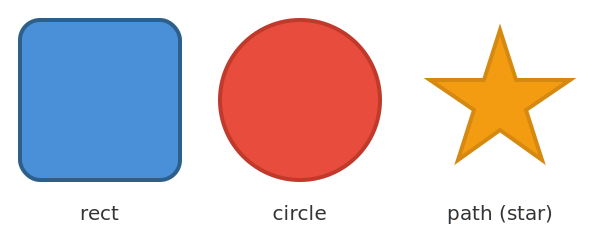

In [5]:
# --- Example 1: Basic shapes ---
basic_svg = '''
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 300 120" width="600" height="240">
  <!-- Rectangle -->
  <rect x="10" y="10" width="80" height="80" rx="10" fill="#4A90D9" stroke="#2C5F8A" stroke-width="2"/>
  <text x="50" y="110" text-anchor="middle" font-size="10" fill="#333">rect</text>

  <!-- Circle -->
  <circle cx="150" cy="50" r="40" fill="#E74C3C" stroke="#C0392B" stroke-width="2"/>
  <text x="150" y="110" text-anchor="middle" font-size="10" fill="#333">circle</text>

  <!-- Path (star) -->
  <path d="M250,15 L258,40 L285,40 L263,55 L271,80 L250,65 L229,80 L237,55 L215,40 L242,40 Z"
        fill="#F39C12" stroke="#D68910" stroke-width="2"/>
  <text x="250" y="110" text-anchor="middle" font-size="10" fill="#333">path (star)</text>
</svg>
'''

display(SVG(data=basic_svg))

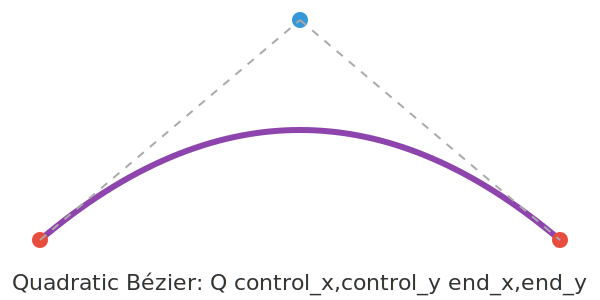

In [6]:
# --- Example 2: Bézier curves ---
bezier_svg = '''
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 300 150" width="600" height="300">
  <!-- Quadratic Bézier -->
  <path d="M 20 120 Q 150 10 280 120" stroke="#8E44AD" fill="none" stroke-width="3"/>
  <!-- Control point visualization -->
  <circle cx="20" cy="120" r="4" fill="#E74C3C"/>
  <circle cx="150" cy="10" r="4" fill="#3498DB"/>
  <circle cx="280" cy="120" r="4" fill="#E74C3C"/>
  <line x1="20" y1="120" x2="150" y2="10" stroke="#aaa" stroke-dasharray="4"/>
  <line x1="150" y1="10" x2="280" y2="120" stroke="#aaa" stroke-dasharray="4"/>
  <text x="150" y="145" text-anchor="middle" font-size="11" fill="#333">
    Quadratic Bézier: Q control_x,control_y end_x,end_y
  </text>
</svg>
'''

display(SVG(data=bezier_svg))

---
## Part 2: Building an Anime Character in SVG

Let's create **Pikachu** — one of the most recognizable anime/game characters — entirely in SVG code. This demonstrates how complex illustrations are composed from simple primitives.

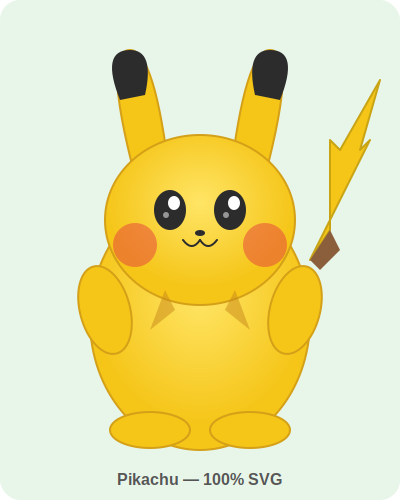

In [7]:
pikachu_svg = '''
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 400 500" width="400" height="500">
  <defs>
    <radialGradient id="bodyGrad" cx="50%" cy="40%" r="50%">
      <stop offset="0%" stop-color="#FFE566"/>
      <stop offset="100%" stop-color="#F5C518"/>
    </radialGradient>
  </defs>

  <!-- ===== BACKGROUND ===== -->
  <rect width="400" height="500" rx="20" fill="#E8F5E9"/>

  <!-- ===== TAIL ===== -->
  <polygon points="310,260 370,140 360,150 380,80 340,150 330,140 330,230"
           fill="#F5C518" stroke="#C8A415" stroke-width="2"
           stroke-linejoin="round"/>
  <!-- Tail brown base -->
  <polygon points="310,260 330,230 340,250 320,270" fill="#8B5E3C"/>

  <!-- ===== BODY ===== -->
  <ellipse cx="200" cy="320" rx="110" ry="130" fill="url(#bodyGrad)"
           stroke="#D4A017" stroke-width="2"/>

  <!-- ===== FEET ===== -->
  <ellipse cx="150" cy="430" rx="40" ry="18" fill="#F5C518" stroke="#D4A017" stroke-width="2"/>
  <ellipse cx="250" cy="430" rx="40" ry="18" fill="#F5C518" stroke="#D4A017" stroke-width="2"/>

  <!-- ===== ARMS ===== -->
  <ellipse cx="105" cy="310" rx="25" ry="45" fill="#F5C518" stroke="#D4A017" stroke-width="2"
           transform="rotate(-15, 105, 310)"/>
  <ellipse cx="295" cy="310" rx="25" ry="45" fill="#F5C518" stroke="#D4A017" stroke-width="2"
           transform="rotate(15, 295, 310)"/>

  <!-- ===== LEFT EAR ===== -->
  <path d="M 140 195 Q 100 50 130 50 Q 155 50 170 180"
        fill="#F5C518" stroke="#D4A017" stroke-width="2"/>
  <!-- Ear tip (black) -->
  <path d="M 120 100 Q 100 50 130 50 Q 155 50 145 95"
        fill="#2C2C2C"/>

  <!-- ===== RIGHT EAR ===== -->
  <path d="M 260 195 Q 300 50 270 50 Q 245 50 230 180"
        fill="#F5C518" stroke="#D4A017" stroke-width="2"/>
  <!-- Ear tip (black) -->
  <path d="M 280 100 Q 300 50 270 50 Q 245 50 255 95"
        fill="#2C2C2C"/>

  <!-- ===== HEAD ===== -->
  <ellipse cx="200" cy="220" rx="95" ry="85" fill="url(#bodyGrad)"
           stroke="#D4A017" stroke-width="2"/>

  <!-- ===== EYES ===== -->
  <!-- Left eye -->
  <ellipse cx="170" cy="210" rx="16" ry="20" fill="#2C2C2C"/>
  <ellipse cx="174" cy="203" rx="6" ry="7" fill="white"/>
  <ellipse cx="166" cy="215" rx="3" ry="3" fill="white" opacity="0.5"/>
  <!-- Right eye -->
  <ellipse cx="230" cy="210" rx="16" ry="20" fill="#2C2C2C"/>
  <ellipse cx="234" cy="203" rx="6" ry="7" fill="white"/>
  <ellipse cx="226" cy="215" rx="3" ry="3" fill="white" opacity="0.5"/>

  <!-- ===== NOSE ===== -->
  <ellipse cx="200" cy="233" rx="5" ry="3" fill="#2C2C2C"/>

  <!-- ===== MOUTH ===== -->
  <path d="M 183 240 Q 192 252 200 240" fill="none" stroke="#2C2C2C" stroke-width="2" stroke-linecap="round"/>
  <path d="M 200 240 Q 208 252 217 240" fill="none" stroke="#2C2C2C" stroke-width="2" stroke-linecap="round"/>

  <!-- ===== CHEEKS (red circles) ===== -->
  <circle cx="135" cy="245" r="22" fill="#E74C3C" opacity="0.55"/>
  <circle cx="265" cy="245" r="22" fill="#E74C3C" opacity="0.55"/>

  <!-- ===== BELLY STRIPES ===== -->
  <path d="M 165 290 L 150 330 L 175 310 Z" fill="#C8881A" opacity="0.5"/>
  <path d="M 235 290 L 250 330 L 225 310 Z" fill="#C8881A" opacity="0.5"/>

  <!-- ===== LABEL ===== -->
  <text x="200" y="485" text-anchor="middle" font-family="Arial, sans-serif"
        font-size="16" font-weight="bold" fill="#555">Pikachu — 100% SVG</text>
</svg>
'''

display(SVG(data=pikachu_svg))

### Rendering SVG to a Raster Image

For evaluation and comparison, we often need to **rasterize** SVGs to PNG. The `cairosvg` library handles this:

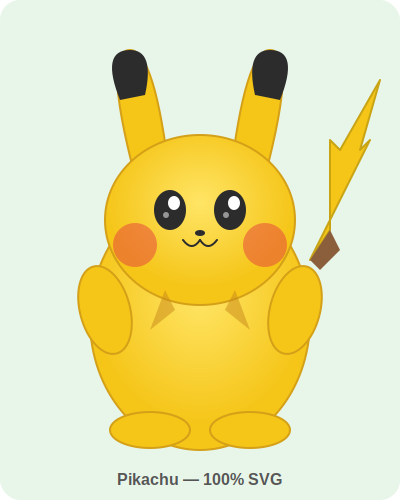

SVG source: 3359 characters
PNG output:  48,982 bytes


In [8]:
# Render SVG to PNG using cairosvg
png_bytes = cairosvg.svg2png(bytestring=pikachu_svg.encode('utf-8'),
                              output_width=400, output_height=500)

# Display the rasterized version
display(Image(data=png_bytes, format='png'))
print(f"SVG source: {len(pikachu_svg)} characters")
print(f"PNG output:  {len(png_bytes):,} bytes")

### SVG for LLMs — The Token Perspective

When we ask a language model to **generate** SVG, it produces text tokens that form valid XML. This is why SVG generation is fundamentally a **code generation** task:

In [9]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-Coder-0.5B")
tokens = tokenizer.encode(pikachu_svg)

print(f"Pikachu SVG length: {len(pikachu_svg)} characters")
print(f"Token count (Qwen2.5-Coder): {len(tokens)} tokens")
print(f"\nFirst 20 tokens decoded:")
for i, tok in enumerate(tokens[:20]):
    print(f"  [{i:2d}] {tok:6d} → {repr(tokenizer.decode([tok]))}")

/root/.venv/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (6.0.0.post1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
/root/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Pikachu SVG length: 3359 characters
Token count (Qwen2.5-Coder): 1557 tokens

First 20 tokens decoded:
  [ 0]    198 → '\n'
  [ 1]     27 → '<'
  [ 2]  15196 → 'svg'
  [ 3]  24967 → ' xmlns'
  [ 4]    428 → '="'
  [ 5]   1254 → 'http'
  [ 6]   1110 → '://'
  [ 7]   2136 → 'www'
  [ 8]   1418 → '.w'
  [ 9]     18 → '3'
  [10]   2659 → '.org'
  [11]     14 → '/'
  [12]     17 → '2'
  [13]     15 → '0'
  [14]     15 → '0'
  [15]     15 → '0'
  [16]  32800 → '/svg'
  [17]      1 → '"'
  [18]  37996 → ' viewBox'
  [19]    428 → '="'


---
## Part 3: LoRA Fine-Tuning — Theory

### The Problem: Full Fine-Tuning is Expensive

To adapt a pre-trained LLM (e.g., Qwen2.5-Coder with 1.5B+ parameters) for SVG generation, **full fine-tuning** updates every parameter:

$$\mathcal{L}(\theta) = \sum_{i=1}^{N} -\log P_{\theta}(y_i \mid x_i)$$

where $\theta$ represents **all** model parameters. For a 1.5B model in float32, that's ~6 GB of parameters, plus ~18 GB for optimizer states (Adam). This is often impractical.

### LoRA: Low-Rank Adaptation (Hu et al., 2021)

**Key insight:** The weight updates during fine-tuning have **low intrinsic rank**. Instead of updating the full weight matrix $W \in \mathbb{R}^{d \times k}$, we decompose the update into two low-rank matrices:

$$W' = W + \Delta W = W + BA$$

where:
- $B \in \mathbb{R}^{d \times r}$ and $A \in \mathbb{R}^{r \times k}$
- $r \ll \min(d, k)$ is the **rank** (typically 4, 8, 16, 32, or 64)
- The original $W$ is **frozen** — only $A$ and $B$ are trained

**Parameter savings:** For a linear layer $W \in \mathbb{R}^{4096 \times 4096}$:
- Full fine-tuning: $4096^2 = 16,777,216$ parameters
- LoRA with $r=16$: $(4096 \times 16) \times 2 = 131,072$ parameters (**0.78%** of original!)

### How LoRA Works — Step by Step

```
              ┌─────────────────────────┐
              │   Original Layer (Frozen)│
   x ───────►│      h = Wx              │───► h + ΔWx
      │       └─────────────────────────┘        ▲
      │                                          │
      │       ┌──────┐    ┌──────┐              │
      └──────►│  A   │───►│  B   │──── (α/r) ──┘
              │ r × k│    │ d × r│
              └──────┘    └──────┘
              Trainable low-rank adapters
```

During the forward pass:
$$h = Wx + \frac{\alpha}{r} \cdot BAx$$

where $\alpha$ is a scaling hyperparameter (often set equal to $r$ so the scaling is 1.0).

### Initialization

- $A$ is initialized with **random Gaussian** values
- $B$ is initialized to **zeros**
- This ensures $\Delta W = BA = 0$ at the start → the model begins at its pre-trained state

### Key Hyperparameters

| Parameter | Typical Values | Effect |
|-----------|---------------|--------|
| `r` (rank) | 4, 8, 16, 32, 64 | Higher = more expressive but more parameters |
| `lora_alpha` | Usually = `r` | Scaling factor; `alpha/r` controls update magnitude |
| `target_modules` | `q_proj, v_proj, k_proj, o_proj, gate_proj, up_proj, down_proj` | Which layers to adapt |
| `lora_dropout` | 0.0 – 0.1 | Regularization on LoRA layers |

### QLoRA — Quantized LoRA (Dettmers et al., 2023)

QLoRA combines LoRA with **4-bit quantization** of the base model:

1. Base model weights are quantized to **NF4** (NormalFloat 4-bit) format
2. LoRA adapters remain in **BF16/FP16** for training stability
3. Double quantization further reduces memory by quantizing the quantization constants

This allows fine-tuning a **7B model on a single 24 GB GPU** — essential for this competition!

### LoRA vs. Other PEFT Methods

| Method | Parameters Trained | Memory | Inference Cost | Merge-able? |
|--------|-------------------|--------|----------------|-------------|
| **Full Fine-Tuning** | 100% | Very High | Same | N/A |
| **LoRA** | ~0.1–1% | Low | Same (after merge) | **Yes** |
| **QLoRA** | ~0.1–1% | Very Low (4-bit base) | Same (after merge) | **Yes** |
| **Prefix Tuning** | ~0.1% | Low | Slightly higher | No |
| **Adapters** | ~1–3% | Low | Higher (extra layers) | No |
| **Prompt Tuning** | ~0.01% | Very Low | Same | No |

LoRA's key advantage: after training, the adapter weights can be **merged** back into the base model ($W' = W + BA$), resulting in **zero additional inference cost**.

---
## Part 4: LoRA Fine-Tuning — Code

Below is a practical walkthrough of setting up LoRA fine-tuning for SVG generation using HuggingFace's `peft` and `transformers` libraries.

In [10]:
# Install required packages (uncomment if needed)
# !pip install transformers peft accelerate bitsandbytes datasets trl cairosvg

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, TaskType, prepare_model_for_kbit_training

# ---------- 1. Model & Tokenizer ----------
MODEL_ID = "Qwen/Qwen2.5-Coder-1.5B-Instruct"  # Good balance of size and capability

# QLoRA: load base model in 4-bit
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",             # NormalFloat 4-bit
    bnb_4bit_compute_dtype=torch.bfloat16,  # Compute in BF16
    bnb_4bit_use_double_quant=True,         # Double quantization
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.bfloat16,
)

# Prepare model for k-bit training (freezes base, enables gradient checkpointing)
model = prepare_model_for_kbit_training(model)

print(f"Model loaded: {MODEL_ID}")
print(f"Model dtype: {model.dtype}")
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

In [ ]:
# ---------- 2. LoRA Configuration ----------
lora_config = LoraConfig(
    r=16,                     # Rank — start with 16, increase if underfitting
    lora_alpha=32,            # Scaling: effective lr multiplier = alpha/r = 2.0
    lora_dropout=0.05,        # Light regularization
    target_modules=[          # Which linear layers to add LoRA to
        "q_proj", "k_proj", "v_proj", "o_proj",  # Attention
        "gate_proj", "up_proj", "down_proj",      # MLP (feed-forward)
    ],
    bias="none",              # Don't train biases
    task_type=TaskType.CAUSAL_LM,
)

# Apply LoRA to the model
model = get_peft_model(model, lora_config)

# Print trainable vs. total parameters
model.print_trainable_parameters()
# Output example: "trainable params: 6,815,744 || all params: 1,549,507,584 || trainable%: 0.4399"

In [ ]:
# ---------- 3. Inspecting LoRA Layers ----------
# Let's see what LoRA actually added to the model

print("Layers with LoRA adapters:\n")
for name, module in model.named_modules():
    if "lora" in name.lower() and hasattr(module, 'weight'):
        print(f"  {name}: {module.weight.shape}")

In [ ]:
# ---------- 4. Dataset Preparation ----------
# For SVG fine-tuning, each sample is a (prompt, SVG_code) pair formatted for instruction tuning

def format_svg_sample(prompt: str, svg_code: str) -> str:
    """Format a prompt-SVG pair into the chat template expected by the model."""
    messages = [
        {"role": "system", "content": "You are an expert SVG code generator. Generate clean, valid SVG code based on the user's description."},
        {"role": "user", "content": prompt},
        {"role": "assistant", "content": svg_code},
    ]
    return tokenizer.apply_chat_template(messages, tokenize=False)

# Example
sample = format_svg_sample(
    prompt="A red circle centered on a white background",
    svg_code='<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 100 100"><circle cx="50" cy="50" r="40" fill="red"/></svg>'
)
print("Formatted training sample:")
print(sample[:500])

In [ ]:
# ---------- 5. Training Setup (using SFTTrainer from TRL) ----------
from transformers import TrainingArguments

# These are reference training arguments — adjust based on your GPU and dataset size
training_args = TrainingArguments(
    output_dir="./svg-lora-checkpoints",
    num_train_epochs=3,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,       # Effective batch size = 2 * 8 = 16
    learning_rate=2e-4,                  # LoRA typically uses higher LR than full FT
    lr_scheduler_type="cosine",
    warmup_ratio=0.05,
    bf16=True,                           # Use BF16 mixed precision
    logging_steps=10,
    save_strategy="steps",
    save_steps=200,
    optim="paged_adamw_8bit",            # Memory-efficient optimizer
    gradient_checkpointing=True,         # Trade compute for memory
    max_grad_norm=0.3,
    report_to="none",                    # Set to "wandb" for experiment tracking
)

print("Training arguments configured.")
print(f"Effective batch size: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")

In [ ]:
# ---------- 6. Training Loop (reference — requires a dataset) ----------
# Uncomment and adapt once you have your SVG dataset loaded

# from trl import SFTTrainer
#
# trainer = SFTTrainer(
#     model=model,
#     args=training_args,
#     train_dataset=train_dataset,         # Your HuggingFace Dataset object
#     processing_class=tokenizer,
#     max_seq_length=2048,                  # SVGs can be long — adjust as needed
# )
#
# trainer.train()
#
# # Save the LoRA adapter (small file — typically 10-50 MB)
# model.save_pretrained("./svg-lora-adapter")
# tokenizer.save_pretrained("./svg-lora-adapter")

print("Training loop ready — uncomment and provide your dataset to start training!")

In [ ]:
# ---------- 7. Loading and Merging LoRA Weights ----------
# After training, you can either:
#   (a) Load the adapter on top of the base model
#   (b) Merge the adapter into the base model for faster inference

from peft import PeftModel

# Option (a): Load adapter
# model = AutoModelForCausalLM.from_pretrained(MODEL_ID, device_map="auto")
# model = PeftModel.from_pretrained(model, "./svg-lora-adapter")

# Option (b): Merge and unload (no overhead at inference time)
# model = model.merge_and_unload()
# model.save_pretrained("./svg-model-merged")

print("After training, merge LoRA weights for zero-overhead inference:")
print("  model = model.merge_and_unload()")
print("  # W' = W + (alpha/r) * B @ A  →  single matrix, no adapter overhead")

---
## Summary

| Topic | Key Takeaway |
|-------|-------------|
| **SVG** | XML-based vector format; infinite scalability; LLMs can generate it as code tokens |
| **SVG Primitives** | `rect`, `circle`, `ellipse`, `path` (Bézier curves), `polygon`, `text`, `g` (groups) |
| **Rendering** | `cairosvg` converts SVG → PNG for evaluation; `IPython.display.SVG` for inline display |
| **LoRA** | Decomposes weight update as $\Delta W = BA$ with rank $r \ll d$; trains <1% of parameters |
| **QLoRA** | 4-bit NF4 quantized base + BF16 LoRA adapters → fine-tune large models on consumer GPUs |
| **Merging** | After training: `merge_and_unload()` folds adapters back → zero inference overhead |

### Next Steps
1. Explore the competition training data in `competition_assets/datasets/svg-train-public/`
2. Prepare your dataset using the `format_svg_sample()` function above
3. Fine-tune with QLoRA and experiment with different `r`, `target_modules`, and learning rates
4. Evaluate outputs using the competition metric (see `competition_assets/evaluation/`)